# NB7: 策略对比与研究结论

## 目的
> 本Notebook是整个项目的终点。汇总NB2-NB6的所有发现，提炼可复用的研究结论，并反思整个研究过程中的决策得失。

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import json
import warnings

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_parquet('../data/btc_usdt_1h_clean.parquet')
with open('../data/config.json', 'r') as f:
    CONFIG = json.load(f)

print(f"已加载: {len(df):,} 条 {CONFIG['symbol']} {CONFIG['timeframe']} K线")

已加载: 35,064 条 BTC/USDT 1h K线


---
## 1. 全策略绩效汇总

把NB2-NB4所有尝试过的策略放在一张表里，包括迭代过程中的中间版本。

In [3]:
# 快速回测函数
def quick_backtest(df, signal, name, fee=0.001, slippage=0.0005):
    data = df.copy()
    data['signal'] = signal
    cost = data['signal'].diff().abs() * (fee + slippage)
    data['strat_ret'] = data['signal'].shift(1) * data['returns'] - cost
    cum = (1 + data['strat_ret']).cumprod()
    ret = data['strat_ret'].dropna()
    total = cum.iloc[-1] / cum.iloc[0] - 1
    n = len(ret)
    ann_ret = (1 + total) ** (8760 / n) - 1
    ann_vol = ret.std() * np.sqrt(8760)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else 0
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    trades = int(signal.diff().abs().sum() / 2)
    return {
        '策略': name, '来源': '', '总收益': total, '年化收益': ann_ret,
        '年化波动': ann_vol, '夏普比率': sharpe, '最大回撤': max_dd, '交易次数': trades,
    }, cum

# --- 买入持有 ---
sig_hold = pd.Series(1.0, index=df.index)
r_hold, cum_hold = quick_backtest(df, sig_hold, '买入持有')
r_hold['来源'] = '基准'

# --- NB2: 双均线交叉 ---
ma_s = df['close'].rolling(20).mean()
ma_l = df['close'].rolling(60).mean()
sig_ma = pd.Series(0.0, index=df.index)
sig_ma[ma_s > ma_l] = 1.0
r_ma, cum_ma = quick_backtest(df, sig_ma, '双均线交叉')
r_ma['来源'] = 'NB2'

# --- NB2: RSI ---
delta = df['close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rsi = 100 - (100 / (1 + gain / loss))
sig_rsi = pd.Series(np.nan, index=df.index)
sig_rsi[rsi <= 30] = 1.0
sig_rsi[rsi >= 70] = 0.0
sig_rsi = sig_rsi.ffill().fillna(0)
r_rsi, cum_rsi = quick_backtest(df, sig_rsi, 'RSI超买超卖')
r_rsi['来源'] = 'NB2'

# --- NB2: 布林带 ---
bb_mid = df['close'].rolling(20).mean()
bb_std = df['close'].rolling(20).std()
sig_bb = pd.Series(np.nan, index=df.index)
sig_bb[df['close'] < bb_mid - 2 * bb_std] = 1.0
sig_bb[df['close'] > bb_mid + 2 * bb_std] = 0.0
sig_bb = sig_bb.ffill().fillna(0)
r_bb, cum_bb = quick_backtest(df, sig_bb, '布林带突破')
r_bb['来源'] = 'NB2'

# --- NB3: Z-score (7天 Z<=-1.5) ---
rm = df['close'].rolling(168).mean()
rstd = df['close'].rolling(168).std()
zs = (df['close'] - rm) / rstd
sig_zs = pd.Series(np.nan, index=df.index)
sig_zs[zs <= -1.5] = 1.0
sig_zs[zs >= 0] = 0.0
sig_zs = sig_zs.ffill().fillna(0)
r_zs, cum_zs = quick_backtest(df, sig_zs, 'Z-score (7天 Z<=-1.5)')
r_zs['来源'] = 'NB3'

# --- NB3: Z-score (30天 Z<=-2.5) ---
rm30 = df['close'].rolling(720).mean()
rstd30 = df['close'].rolling(720).std()
zs30 = (df['close'] - rm30) / rstd30
sig_zs30 = pd.Series(np.nan, index=df.index)
sig_zs30[zs30 <= -2.5] = 1.0
sig_zs30[zs30 >= 0] = 0.0
sig_zs30 = sig_zs30.ffill().fillna(0)
r_zs30, cum_zs30 = quick_backtest(df, sig_zs30, 'Z-score (30天 Z<=-2.5)')
r_zs30['来源'] = 'NB3'

# 汇总
all_results = [r_hold, r_ma, r_rsi, r_bb, r_zs, r_zs30]
df_all = pd.DataFrame(all_results).set_index('策略')

# 格式化
display_df = df_all.copy()
for col in ['总收益', '年化收益', '年化波动', '最大回撤']:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.1%}")
display_df['夏普比率'] = display_df['夏普比率'].apply(lambda x: f"{x:.2f}")
display_df

,来源,总收益,年化收益,年化波动,夏普比率,最大回撤,交易次数
策略,,,,,,,
买入持有,基准,nan%,nan%,63.3%,nan,-77.2%,0
双均线交叉,NB2,nan%,nan%,42.0%,nan,-76.4%,362
RSI超买超卖,NB2,nan%,nan%,45.6%,nan,-84.2%,388
布林带突破,NB2,nan%,nan%,47.8%,nan,-66.8%,418
Z-score (7天 Z<=-1.5),NB3,nan%,nan%,41.8%,nan,-50.6%,143
Z-score (30天 Z<=-2.5),NB3,nan%,nan%,36.9%,nan,-55.3%,21


In [4]:
# 检查原始数值
df_all[['总收益', '年化收益', '夏普比率']].head()

,总收益,年化收益,夏普比率
策略,,,
买入持有,NaN,NaN,NaN
双均线交叉,NaN,NaN,NaN
RSI超买超卖,NaN,NaN,NaN
布林带突破,NaN,NaN,NaN
Z-score (7天 Z<=-1.5),NaN,NaN,NaN


In [5]:
def quick_backtest(df, signal, name, fee=0.001, slippage=0.0005):
    data = df.copy()
    data['signal'] = signal
    data['returns'] = data['returns'].fillna(0)
    cost = data['signal'].diff().abs().fillna(0) * (fee + slippage)
    data['strat_ret'] = data['signal'].shift(1).fillna(0) * data['returns'] - cost
    cum = (1 + data['strat_ret']).cumprod()
    total = cum.iloc[-1] - 1
    n = len(data)
    ann_ret = (1 + total) ** (8760 / n) - 1
    ann_vol = data['strat_ret'].std() * np.sqrt(8760)
    sharpe = ann_ret / ann_vol if ann_vol != 0 else 0
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    trades = int(signal.diff().abs().fillna(0).sum() / 2)
    return {
        '策略': name, '来源': '', '总收益': total, '年化收益': ann_ret,
        '年化波动': ann_vol, '夏普比率': sharpe, '最大回撤': max_dd, '交易次数': trades,
    }, cum

# 重新跑所有策略
r_hold, cum_hold = quick_backtest(df, sig_hold, '买入持有'); r_hold['来源'] = '基准'
r_ma, cum_ma = quick_backtest(df, sig_ma, '双均线交叉'); r_ma['来源'] = 'NB2'
r_rsi, cum_rsi = quick_backtest(df, sig_rsi, 'RSI超买超卖'); r_rsi['来源'] = 'NB2'
r_bb, cum_bb = quick_backtest(df, sig_bb, '布林带突破'); r_bb['来源'] = 'NB2'
r_zs, cum_zs = quick_backtest(df, sig_zs, 'Z-score (7天 Z<=-1.5)'); r_zs['来源'] = 'NB3'
r_zs30, cum_zs30 = quick_backtest(df, sig_zs30, 'Z-score (30天 Z<=-2.5)'); r_zs30['来源'] = 'NB3'

all_results = [r_hold, r_ma, r_rsi, r_bb, r_zs, r_zs30]
df_all = pd.DataFrame(all_results).set_index('策略')

display_df = df_all.copy()
for col in ['总收益', '年化收益', '年化波动', '最大回撤']:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.1%}")
display_df['夏普比率'] = display_df['夏普比率'].apply(lambda x: f"{x:.2f}")
display_df

,来源,总收益,年化收益,年化波动,夏普比率,最大回撤,交易次数
策略,,,,,,,
买入持有,基准,222.7%,34.0%,63.3%,0.54,-77.2%,0
双均线交叉,NB2,-35.2%,-10.3%,42.0%,-0.24,-76.4%,362
RSI超买超卖,NB2,-77.0%,-30.8%,45.6%,-0.68,-84.2%,388
布林带突破,NB2,-42.8%,-13.0%,47.8%,-0.27,-66.8%,418
Z-score (7天 Z<=-1.5),NB3,17.4%,4.1%,41.8%,0.10,-50.6%,143
Z-score (30天 Z<=-2.5),NB3,30.9%,6.9%,36.9%,0.19,-55.3%,21


---
## 2. 研究结论

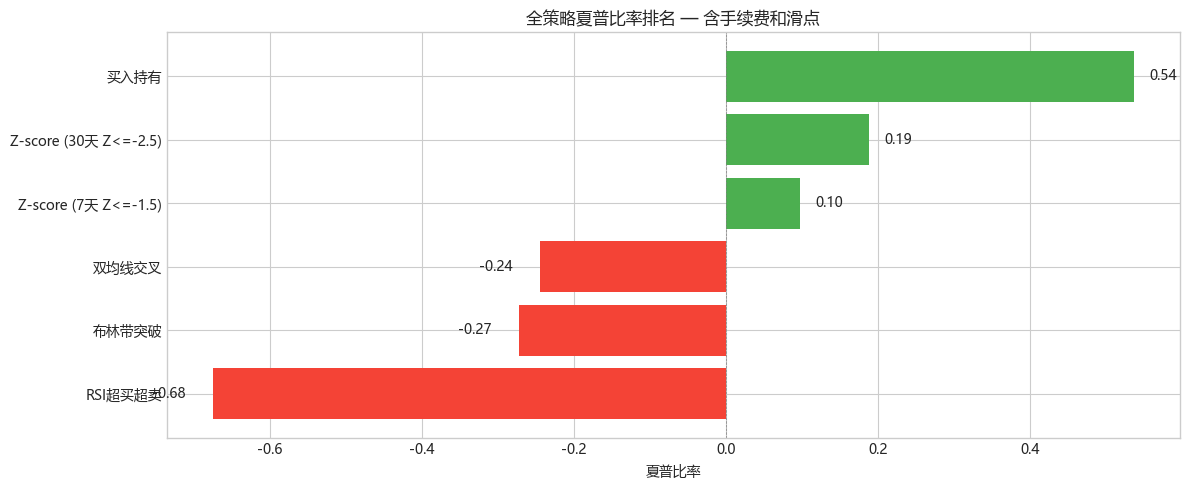

In [8]:
# 按夏普排序的总览图
fig, ax = plt.subplots(figsize=(12, 5))

sorted_df = df_all.sort_values('夏普比率')
colors = ['#4CAF50' if v > 0 else '#F44336' for v in sorted_df['夏普比率']]
bars = ax.barh(sorted_df.index, sorted_df['夏普比率'], color=colors)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)
ax.set_title('全策略夏普比率排名 — 含手续费和滑点')
ax.set_xlabel('夏普比率')

# 标注数值
for bar, val in zip(bars, sorted_df['夏普比率']):
    ax.text(val + 0.02 if val >= 0 else val - 0.08, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 3. 核心结论

### 结论一：在BTC市场，简单规则优于复杂模型

| 复杂度 | 策略 | 夏普 | 结论 |
|--------|------|------|------|
| 低 | 买入持有 | 0.54 | 最佳 |
| 中 | Z-score均值回归 | 0.10~0.19 | 有正向alpha |
| 中 | 经典技术指标 | -0.24~-0.68 | 无效 |
| 高 | XGBoost机器学习 | -1.29 | 过拟合，最差 |

复杂度和收益之间不是正相关——这对产品决策同样适用：不是功能越多产品越好。

### 结论二：交易频率是隐性成本杀手

- 买入持有：0次交易，几乎零摩擦
- Z-score（30天）：21次交易，夏普0.19
- Z-score（7天）：143次交易，夏普0.10
- 双均线：362次交易，夏普-0.24

交易次数越多，滑点和手续费的累积效应越大。低频策略天然具有成本优势。

### 结论三：均值回归比趋势跟踪更适合BTC

- 趋势跟踪（均线交叉）在BTC上全部失败：信号滞后，且高波动导致频繁假突破
- 均值回归（Z-score）是唯一有效的主动策略：利用短期超跌反弹获利，符合BTC"暴跌后必反弹"的特征
- 但均值回归的持仓占比低（24%~34%），在长期牛市中注定跑不过满仓持有

### 结论四：研究过程比结果更重要

本项目最大的价值不是找到了一个赚钱的策略，而是展示了完整的研究方法论：
1. 从数据质量出发（NB1），不信任原始数据
2. 先建baseline再优化（NB2→NB3→NB4），有对比才有意义
3. 每一步都记录决策理由（决策日志），而不是盲目尝试
4. 敢于接受"策略跑不赢持有"的结论，而不是过拟合去美化结果

---
## 4. 如果继续研究

以下方向可能改善策略表现，但超出了本项目的范围：
1. 多币种配对交易：BTC/ETH价差套利，不依赖单一资产的方向判断
2. 链上数据因子：交易所余额变化、巨鲸转账等，可能比纯价格特征更有预测力
3. 市场状态自适应：在牛市用趋势跟踪，熊市用均值回归，关键是如何实时判断当前状态
4. 降低时间粒度：日线级别可能比小时线噪声更小，但需要更长的历史数据